<a href="https://colab.research.google.com/github/grewtech1000/AIFFEL_quest_eng/blob/main/NLP/NLP02/translate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 들어가며
- matplotlib 라이브러리의 기본 폰트는 한국어를 지원하지 않음
- 올바른 Attention Map을 확인하기 위해 한국어를 지원하는 폰트로 변경

In [2]:
!mkdir -p ~/work/transformer

In [3]:
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 런타임 재시작 (폰트 적용을 위해 필수)

# 3. 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (58.3 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/

# 2. 내부 모듈 구현하기

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

print(torch.__version__)

2.10.0+cu128


## Positional Encoding
- 각 위치를 나타내는 벡터로 인코딩

---

In [5]:

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


## Multi-Head Attention
---

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads # 헤드의 수
        self.d_model = d_model # 입쳑 차원의 수

        self.depth = d_model // self.num_heads # 병렬로 어텐션 수행할 차원 수

        self.W_q = nn.Linear(d_model, d_model)  # Q벡터 가중치를 위한 Linear Layer
        self.W_k = nn.Linear(d_model, d_model)  # K벡터 가중치를 위한 Linear Layer
        self.W_v = nn.Linear(d_model, d_model) # V벡터 가중치를 위한 Linear Layer

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1) # K벡터의 차원
        QK = torch.matmul(Q, K.transpose(-2, -1)) # Q * K의 내적. 내적이 가능하기 위해 K의 전치행렬을 곱함

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32)) # 값이 너무 커지지 않도록 k차원의 루트값으로 나누

        if mask is not None: # mask대상이 가 존재하면
            scaled_qk += (mask * -1e9) # mask가 1로 지정된 위치에 -e9를 곱해 -inf의 값으로 설정

        attentions = F.softmax(scaled_qk, dim=-1)  # Q,K의 유사도를 확률로 표현
        out = torch.matmul(attentions, V) # Q,K의 유사도를 확률을 V에 내적

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        #Q,K,V의 가중치 벡터
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 병렬처리를 위해 분할
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # out, attention_weights를 구한 후
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        # 병렬 처리 값을 병합
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")

슝=3



## Position-wise Feed-Forward Network
---

In [7]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()


    def forward(self, x):
       # 토큰별로 ffn을 통과
        out = self.relu(self.w_1(x))
        out = self.w_2(out)

        return out

print("슝=3")

슝=3


# 3. 모듈 조립하기

## Encoder 레이어 구현하기
---
그럼 본격적으로 레이어를 디자인해보죠! 먼저 `EncoderLayer` 구현을 예시로 보여드릴게요. 이를 참고하여 `DecoderLayer` 를 구현하시면 됩니다!

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x # 잔차 저장
        out = self.norm_1(x) # 정규화
        out, enc_attn = self.enc_self_attn(out, out, out, mask) # MultiHeadAttention 수행
        out = self.dropout(out)   # 드롭아웃
        out += residual # 잔차 합산: 빠른 수렴과 기울기 소실 방지

        """
        Position-Wise Feed Forward Network
        """
        residual = out  # 잔차 저장
        out = self.norm_2(out) # 정규화
        out = self.ffn(out) # FFN 통과 표현력 증가
        out = self.dropout(out) # 드롭아웃
        out += residual # 잔차 합산

        return out, enc_attn

print("슝=3")

슝=3


## Decoder 레이어 구현하기
---
위 `EncoderLayer` 클래스를 참고하여 `DecoderLayer` 클래스를 완성하세요!

 (참고: Decoder에서는 두 번의 Attention이 진행되니 반환되는 Attention도 두 개겠죠?)

In [9]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


In [10]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []
        #EncoderLayer를 n_layers만큼 생성
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("슝=3")

슝=3


In [11]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [12]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in) # 인코딩 임베딩
        dec_in = self.embedding(self.dec_emb, dec_in) # 디코딩 임베딩

        enc_out, enc_attns = self.encoder(enc_in, enc_mask) # 인코딩 수행

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask) # 디코딩 수행

        logits = self.fc(dec_out) # 디코딩 출력을 출력층 통과

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [13]:
import torch
import numpy as np

# 패딩 마스크 생성
def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    # 미래 입력 토큰 예측할 수 있도록 대각선 윗방향을 1로 처리
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(tgt)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


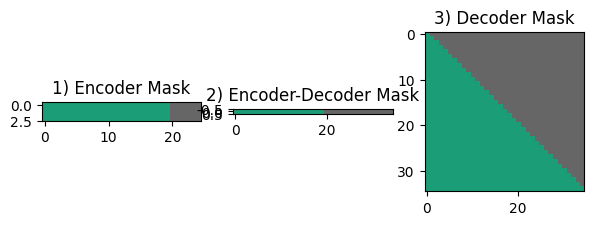

In [14]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

In [15]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("슝=3")

슝=3


# 5. 프로젝트: 더 멋진 번역기 만들기

## Step 1. 라이브러리 & 디바이스

GPU가 있으면 자동으로 GPU를 사용합니다.


In [16]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.10.0+cu128 | device: cuda


## Step 2. 데이터 다운로드

`~/work/transformer/data` 와 `/content` 둘 다 자동 탐색합니다 (로컬/Colab 모두 OK).


In [17]:
HOME = os.getenv("HOME")
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")
print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))


DATA_DIR: /root/work/transformer/data
kor: True eng: True


## Step 3. 정제 & 토큰화

- 중복 제거 (병렬 쌍 유지)
- 소문자화, 특수문자 정리, 문장부호 분리
- SentencePiece 토크나이저 학습 (한/영 각각 8,000 vocab)


In [18]:
def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

def load_pairs(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs

pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]


중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


In [19]:
import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"
    with open(txt_path, "w") as f:
        for row in corpus:
            f.write(row + "\n")

    # FIX: 원본 코드는 공백 누락 + '--pad_id==%d' (등호 두 개) 로 학습이 깨짐.
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print("ko vocab:", ko_tokenizer.get_piece_size(),
      "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))


토크나이저 학습 중...
ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


## Step 4. 텐서화 (길이 ≤ 40 만 사용)


In [20]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []
for k, e in zip(kor_corpus, eng_corpus):
    s = ko_tokenizer.encode_as_ids(k)
    t = en_tokenizer.encode_as_ids(e)  # bos/eos 포함
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))


학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


## Step 5. 모델 구성

마스크 컨벤션을 **`True == 가려라(=마스킹)`** 하나로 통일하고, attention 내부에서 `masked_fill(mask, -inf)` 로 처리합니다. 이전 코드는 `mask == 0` 위치를 가려서 *유효 토큰* 이 전부 -inf 가 되는 치명적 버그가 있었어요.


In [21]:
def positional_encoding(pos_len, d_model):
    pe = np.zeros((pos_len, d_model), dtype=np.float32)
    position = np.arange(0, pos_len)[:, None]
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.from_numpy(pe)  # [pos_len, d_model]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        b, t, _ = x.shape
        return x.view(b, t, self.num_heads, self.depth).transpose(1, 2)

    def _combine(self, x):
        b, h, t, d = x.shape
        return x.transpose(1, 2).contiguous().view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        # mask: bool, True 인 위치를 가린다. shape broadcast-able to (B, H, Tq, Tk).
        Q = self._split(self.W_q(Q))
        K = self._split(self.W_k(K))
        V = self._split(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = self._combine(out)
        return self.linear(out), attn


class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.gelu(self.w_1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        h = self.norm_1(x)
        h, attn = self.self_attn(h, h, h, src_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        x = x + self.dropout(self.ffn(h))
        return x, attn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        h = self.norm_1(x)
        h, self_attn = self.self_attn(h, h, h, tgt_mask)
        x = x + self.dropout(h)

        h = self.norm_2(x)
        # FIX: cross-attention 에는 인코더 패딩 마스크만 (causal X)
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)
        x = x + self.dropout(h)

        h = self.norm_3(x)
        x = x + self.dropout(self.ffn(h))
        return x, self_attn, cross_attn


class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        attns = []
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        self_attns, cross_attns = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa); cross_attns.append(ca)
        return x, self_attns, cross_attns


class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)
        if shared:
            self.fc.weight = self.dec_emb.weight

        self._reset_parameters()

    def _reset_parameters(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        # FIX: shared 여부와 무관하게 항상 sqrt(d_model) 스케일
        out = emb(x) * math.sqrt(self.d_model)
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)
        return self.dropout(out)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        enc_in = self._embed(self.enc_emb, src)
        dec_in = self._embed(self.dec_emb, tgt)

        enc_out, enc_attns = self.encoder(enc_in, src_mask)
        dec_out, dec_attns, cross_attns = self.decoder(
            dec_in, enc_out, tgt_mask, memory_mask
        )
        return self.fc(dec_out), enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")


모델 클래스 정의 완료


In [22]:
def padding_mask(seq):
    # True 이면 PAD. shape: [B, 1, 1, T]
    return (seq == 0).unsqueeze(1).unsqueeze(2)

def causal_mask(size, device):
    # True 이면 미래 위치. shape: [1, 1, size, size]
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)
    return m.unsqueeze(0).unsqueeze(0)

def generate_masks(src, tgt):
    src_pad = padding_mask(src)                                # [B,1,1,Ts]
    tgt_pad = padding_mask(tgt)                                # [B,1,1,Tt]
    tgt_causal = causal_mask(tgt.size(1), tgt.device)          # [1,1,Tt,Tt]
    tgt_mask = tgt_pad | tgt_causal                            # broadcast → [B,1,Tt,Tt]
    memory_mask = src_pad                                      # cross-attn 은 enc padding 만
    return src_pad, tgt_mask, memory_mask


## Step 6. 하이퍼파라미터 & 인스턴스화


In [23]:
N_LAYERS = 4
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 1024
DROPOUT  = 0.1
POS_LEN  = MAX_LEN + 2
BATCH_SIZE = 128
EPOCHS = 20
WARMUP_STEPS = 4000
LABEL_SMOOTH = 0.1

model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE, tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN, dropout=DROPOUT, shared=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"파라미터 수: {n_params/1e6:.2f}M")


파라미터 수: 11.47M


## Step 7. Optimizer / Scheduler / Loss

원논문의 Noam 스케줄을 `LambdaLR` 로 깔끔하게 구현합니다. (원본은 optimizer 정의 전에 scheduler를 만드는 순서 버그가 있었어요.)


In [24]:
def noam_lr(d_model, warmup):
    def lr(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)
    return lr

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS))


class LabelSmoothingLoss(nn.Module):
    """Label smoothing + ignore PAD."""
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing

    def forward(self, logits, target):
        # logits: [B, T, V]; target: [B, T]
        logp = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)
            true_dist[:, :, self.pad_id] = 0
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask
        loss = -(true_dist * logp).sum(dim=-1)
        n_tok = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_tok


criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)
print("optimizer / scheduler / loss 준비 완료")


optimizer / scheduler / loss 준비 완료


## Step 8. 미니배치 패딩 & 학습 루프

전체 텐서를 미리 한꺼번에 패딩하면 가장 긴 문장 길이까지 모든 시퀀스가 늘어나서 메모리/속도가 나빠집니다. **배치 단위로만 패딩**해서 학습합니다.


In [25]:
from torch.nn.utils.rnn import pad_sequence

train_idx = list(range(len(src_corpus)))

def make_batch(indices):
    src = pad_sequence([src_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    tgt = pad_sequence([tgt_corpus[i] for i in indices], batch_first=True, padding_value=PAD_ID)
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)
    # NOTE: src_mask, memory_mask 는 본질적으로 같은 인코더 패딩 마스크지만
    # encoder self-attn vs cross-attn 에 같이 쓰입니다.

    optimizer.zero_grad()
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)
    loss = criterion(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    return loss.item()


In [26]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_idx)
    total, n = 0.0, 0
    for s in range(0, len(train_idx), BATCH_SIZE):
        batch = train_idx[s : s + BATCH_SIZE]
        if not batch:
            continue
        src, tgt = make_batch(batch)
        loss = train_step(src, tgt)
        total += loss; n += 1
    print(f"Epoch {epoch:2d} | avg loss {total/max(1,n):.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")


## Step 9. 번역 함수 (Greedy decoding)

- `model.eval()` + `torch.no_grad()`
- 디바이스 이동
- `<unk>` 강제 회피
- 최대 길이 cap


In [ ]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    model.eval()

    sent = preprocess_sentence(sentence)
    src_ids = ko_tokenizer.encode_as_ids(sent)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated = []
    enc_attns = dec_attns = cross_attns = None

    for _ in range(max_len):
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)
        logits, enc_attns, dec_attns, cross_attns = model(
            src, out, src_mask, tgt_mask, memory_mask
        )
        next_logits = logits[0, -1].clone()
        next_logits[UNK_ID] = float("-inf")   # <unk> 회피
        next_id = int(torch.argmax(next_logits).item())

        if next_id == EOS_ID:
            break
        generated.append(next_id)
        out = torch.cat(
            [out, torch.tensor([[next_id]], device=device)], dim=-1
        )

    return en_tokenizer.decode_ids(generated), enc_attns, dec_attns, cross_attns


def translate(sentence):
    result, *_ = evaluate(sentence)
    return result


## Step 10. 번역 예시 10개 출력


In [ ]:
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)
for i, s in enumerate(examples, 1):
    out = translate(s)
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")


In [ ]:
print("hi")

## 🔴 버그 1. Mask 반전 — `masked_fill(mask == 0, -1e9)`

**원본 위치**
- `MultiHeadAttention.scaled_dot_product_attention` 안의 한 줄
- `generate_padding_mask` 의 마스크 의미

**원본 코드**
```python
# padding mask: PAD 위치를 1, 유효 위치를 0 으로 표시
mask = (seq == 0).float()

# attention 안에서
scaled_qk = scaled_qk.masked_fill(mask == 0, float('-1e9'))
#                                       ▲
#                            여기가 거꾸로! 유효 토큰을 가림
```

**수정 코드 (현재 노트북)**
```python
# True = 가린다 로 컨벤션 통일
return (seq == 0).unsqueeze(1).unsqueeze(2)        # bool, PAD=True

scores = scores.masked_fill(mask, float('-inf'))    # True 위치만 -inf
```


In [ ]:
# 데모: 같은 입력에 원본 vs 수정 마스크를 적용했을 때 softmax 결과 비교
import torch, torch.nn.functional as F

# 가짜 attention score (B=1, H=1, Tq=1, Tk=5)
scores = torch.tensor([[[[1.0, 2.0, 3.0, 0.0, 0.0]]]])
seq    = torch.tensor([[10, 20, 30, 0, 0]])   # 뒤 두 개가 PAD

# ── 원본 (버그) ────────────────────────────────
pad_mask_orig = (seq == 0).float().unsqueeze(1).unsqueeze(2)  # PAD=1, 유효=0
sc_orig = scores.masked_fill(pad_mask_orig == 0, float('-1e9'))
attn_orig = F.softmax(sc_orig, dim=-1)

# ── 수정 ──────────────────────────────────────
pad_mask_fix = (seq == 0).unsqueeze(1).unsqueeze(2)           # bool, PAD=True
sc_fix = scores.masked_fill(pad_mask_fix, float('-inf'))
attn_fix = F.softmax(sc_fix, dim=-1)

print("입력 시퀀스 :", seq.tolist()[0], "  (뒤 2개가 PAD)")
print()
print("원본 attention :", attn_orig.squeeze().tolist())
print("  → 유효 토큰(앞 3개)이 0, PAD(뒤 2개)에만 attention. 학습 불가.")
print()
print("수정 attention :", [round(x, 3) for x in attn_fix.squeeze().tolist()])
print("  → 유효 토큰 3개로 attention 정상 분배, PAD 는 0.")


## 🔴 버그 2. Cross-attention 에 causal mask

**원본 위치**
- `generate_masks()` 의 `dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])`
- `DecoderLayer` 의 `enc_dec_attn(out, enc_out, enc_out, causality_mask)` — cross-attn 에 이 마스크가 그대로 들어감

**왜 cross-attention 에는 causal mask 가 있으면 안 되나?**

번역은 **어순이 바뀝니다**. 예: 한국어 *"나는 어제 학교에 갔다"* → 영어 *"I went to school yesterday"*. 영어 첫 단어 `I` 를 만들 때 한국어 `나는` (맨 앞) 을 봐야 하고, `went` 는 한국어 `갔다` (맨 뒤) 를 봐야 합니다. 디코더는 매 시점마다 **인코더 전체** 를 자유롭게 들여다볼 수 있어야 해요.

원본은 cross-attn 에 *"디코더 시점 i 는 인코더의 i 까지만 봐라"* 같은 인과적 제약을 추가했고, 거기에 **버그 1(마스크 반전)** 이 겹쳐서 실제 동작은 **anti-causal (오히려 미래 위치만 봄)** 이 되며 마지막 토큰은 attend 할 게 없어 **NaN 까지 발생** 합니다.

**원본 코드**
```python
dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask)
# DecoderLayer 안에서:
out, _ = self.enc_dec_attn(out, enc_out, enc_out, dec_enc_mask)  # ← cross-attn 에 causal 섞임
```

**수정 코드**
```python
memory_mask = src_pad   # 인코더 PAD 만. cross-attn 은 인코더 전체를 자유롭게 attend.
```


In [ ]:
# 데모: 한국어 4토큰 → 영어 4토큰 번역에서, 각 영어 단어가 어떤 한국어 단어를 볼 수 있는지
# attention 가중치(각 행의 합 = 1)로 직관적으로 비교.
import torch, torch.nn.functional as F

src_words = ["나는", "어제", "학교에", "갔다"]
tgt_words = ["I",    "went", "to",     "school"]   # 생성 중인 영어 토큰

# 가짜 attention score: 모두 1로 동일 → 마스크의 영향만 깨끗하게 보임
scores = torch.ones(1, 1, len(tgt_words), len(src_words))

# ─── 원본 코드의 실제 효과 (버그 1 + 2 결합) ─────────────────────────────────
# 원본 mask:
orig_mask = (1 - torch.cumsum(torch.eye(len(tgt_words), len(src_words)), dim=0)).float()
# 원본 attention 은 masked_fill(mask == 0, -inf) → mask==0 위치가 가려짐
scores_orig = scores.masked_fill(orig_mask == 0, float("-inf"))
attn_orig = F.softmax(scores_orig, dim=-1)

# ─── 수정 코드 (PAD 만 가림, 여기선 PAD 없음 → 전부 attend) ───────────────────
attn_fix = F.softmax(scores, dim=-1)

# 출력 헬퍼
def show(title, attn):
    print(title)
    header = " " * 14 + "  ".join(f"{w:>6}" for w in src_words)
    print(header)
    for i, tw in enumerate(tgt_words):
        row = attn[0, 0, i].tolist()
        cells = "  ".join(
            ("  nan " if v != v else f"{v:6.2f}") for v in row
        )
        print(f"  생성 '{tw:<6}' {cells}")
    print()

show("원본 cross-attention 가중치 (디코더가 인코더의 어디를 보는가)", attn_orig)
print('  → 첫 영어 단어 "I" 를 만들 때 한국어 "나는" 을 못 봄(가중치 0)!')
print('  → 마지막 단어 "school" 은 attend 할 한국어 토큰이 하나도 없어 NaN.')
print()
show("수정 cross-attention 가중치", attn_fix)
print("  → 모든 영어 단어가 모든 한국어 단어를 동등하게 attend 가능.")
print("    (실제 학습에서는 의미적으로 관련된 단어로 가중치가 쏠림)")
